dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

CLASSIFICATION RESULTS (breast_cancer)

                    Model  Accuracy  Precision  Recall (Sensitivity)  F1 Score
0                     KNN  0.912281   0.903247              0.910714  0.906649
1             Naive Bayes  0.938596   0.936017              0.931548  0.933693
2           Decision Tree  0.912281   0.901854              0.915675  0.907468
3     Logistic Regression  0.964912   0.967230              0.957341  0.961911
4  SGD (Gradient Descent)  0.833333   0.825704              0.848214  0.828571


c:\Users\KIIT0001\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


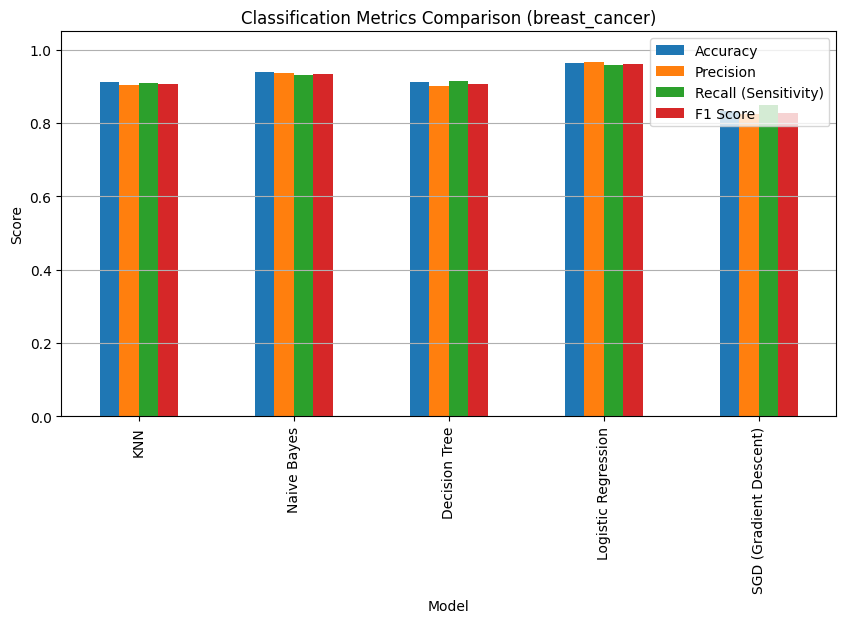

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer  
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,mean_squared_error, r2_score)
breast_cancer = load_breast_cancer()
from sklearn.preprocessing import StandardScaler
print(breast_cancer.keys())

X, y = breast_cancer.data, breast_cancer.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
classifiers = {
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "SGD (Gradient Descent)": SGDClassifier(loss="log_loss", random_state=42)
}
clf_results = []

for name, model in classifiers.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    clf_results.append([
        name,
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred, average="macro"),
        recall_score(y_test, y_pred, average="macro"),   
        f1_score(y_test, y_pred, average="macro")
    ])
clf_df = pd.DataFrame(
    clf_results,
    columns=["Model", "Accuracy", "Precision", "Recall (Sensitivity)", "F1 Score"]
)
print("\nCLASSIFICATION RESULTS (breast_cancer)\n")
print(clf_df)
clf_df.set_index("Model").plot(kind="bar", figsize=(10,5))
plt.title("Classification Metrics Comparison (breast_cancer)")
plt.ylabel("Score")
plt.ylim(0,1.05)
plt.grid(axis="y")
plt.show()



CLASSIFICATION RESULTS (breast_cnacer)

                    Model  Accuracy  Precision  Recall (Sensitivity)  F1 Score
0                     KNN  0.956140   0.955062              0.950397  0.952638
1             Naive Bayes  0.929825   0.924603              0.924603  0.924603
2           Decision Tree  0.912281   0.901854              0.915675  0.907468
3     Logistic Regression  0.982456   0.981151              0.981151  0.981151
4  SGD (Gradient Descent)  0.973684   0.969702              0.974206  0.971863


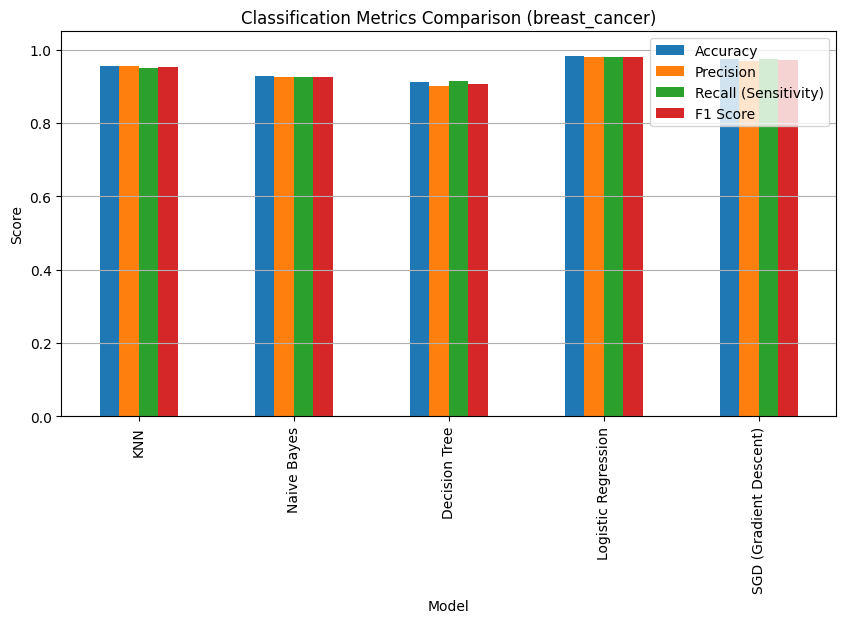

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer  
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,mean_squared_error, r2_score)
breast_cancer = load_breast_cancer()
X, y = breast_cancer.data, breast_cancer.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


classifiers = {
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SGD (Gradient Descent)": SGDClassifier(loss="log_loss", random_state=42)
}
clf_results = []

for name, model in classifiers.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    clf_results.append([
        name,
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred, average="macro"),
        recall_score(y_test, y_pred, average="macro"),   
        f1_score(y_test, y_pred, average="macro")
    ])
clf_df = pd.DataFrame(
    clf_results,
    columns=["Model", "Accuracy", "Precision", "Recall (Sensitivity)", "F1 Score"]
)
print("\nCLASSIFICATION RESULTS (breast_cnacer)\n")
print(clf_df)
clf_df.set_index("Model").plot(kind="bar", figsize=(10,5))
plt.title("Classification Metrics Comparison (breast_cancer)")
plt.ylabel("Score")
plt.ylim(0,1.05)
plt.grid(axis="y")
plt.show()
